# Dataset Creation for Anomaly Detection (Deep Learning)

Create datasets for anomaly detection using deep learning methods (e.g., Autoencoders). Anomalies are defined as records where `active_failures > 0`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INVERTER_RAW_PATH = "../data/bronze/inverter_raw.csv"
METEO_STATION_RAW_PATH = "../data/bronze/meteo_station_raw.csv"

In [2]:
def load_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    if not lines:
        return pd.DataFrame()

    # 1. Get header and count target columns
    header = lines[0].strip().split(',')
    num_cols = len(header)
    
    # 2. Find where the JSON is (it's always the column before the last 4)
    # The last 4 are always: ingestion_timestamp, source, processing_status, error_message
    json_idx = header.index('raw_json')
    cols_after_json = num_cols - (json_idx + 1)

    data_rows = []
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split(',')
        
        # Leading columns (before JSON)
        leading = parts[:json_idx]
        
        # Trailing columns - take exactly the last cols_after_json columns
        trailing = parts[-cols_after_json:]

        # Everything in between is the JSON
        json_parts = parts[json_idx:-cols_after_json]
        json_blob = ",".join(json_parts).strip('"')

        # Combine and ensure we only have the exact number of columns as the header
        full_row = leading + [json_blob] + trailing
        data_rows.append(full_row[:num_cols])

    # Drop columns that are entirely empty or whitespace-only like 'error_message'
    df = pd.DataFrame(data_rows, columns=header)
    df = df.replace(r"^\s*$", pd.NA, regex=True)
    df = df.dropna(axis=1, how='all')

    return df

## Load Data

In [3]:
inverter_raw = load_csv(INVERTER_RAW_PATH)
meteo_station_raw = load_csv(METEO_STATION_RAW_PATH)

In [4]:
inverter = inverter_raw[['inverter_id', 'state', 'timestamp', 'state', 'inverter_temp_c', \
    'ac_power_kw', 'ac_freq_hz', 'dc_power_kw', 'dc_voltage_v', 'dc_current_a', \
    'active_failures', 'healthy_strings', 'failed_strings']].copy()
meteo_station = meteo_station_raw[['timestamp', 'amb_temp_c', 'module_temp_c', \
    'wind_speed_ms', 'wind_dir_deg', 'humidity_percent', 'poa_irradiance_wm2']].copy()

In [5]:
inverter["timestamp"] = pd.to_datetime(inverter["timestamp"], format='ISO8601')
inverter["state"] = inverter["state"].astype(int)
inverter["inverter_temp_c"] = inverter["inverter_temp_c"].astype(float)
inverter["ac_power_kw"] = inverter["ac_power_kw"].astype(float)
inverter["ac_freq_hz"] = inverter["ac_freq_hz"].astype(float)
inverter["dc_power_kw"] = inverter["dc_power_kw"].astype(float)
inverter["dc_voltage_v"] = inverter["dc_voltage_v"].astype(float)
inverter["dc_current_a"] = inverter["dc_current_a"].astype(float)
inverter["active_failures"] = inverter["active_failures"].astype(int)
inverter["healthy_strings"] = inverter["healthy_strings"].astype(int)
inverter["failed_strings"] = inverter["failed_strings"].astype(int)

inverter = inverter.sort_values("timestamp").reset_index(drop=True)

In [6]:
meteo_station["timestamp"] = pd.to_datetime(meteo_station["timestamp"], format='ISO8601')
meteo_station["amb_temp_c"] = meteo_station["amb_temp_c"].astype(float)
meteo_station["module_temp_c"] = meteo_station["module_temp_c"].astype(float)
meteo_station["wind_speed_ms"] = meteo_station["wind_speed_ms"].astype(float)
meteo_station["wind_dir_deg"] = meteo_station["wind_dir_deg"].astype(float)
meteo_station["humidity_percent"] = meteo_station["humidity_percent"].astype(float)
meteo_station["poa_irradiance_wm2"] = meteo_station["poa_irradiance_wm2"].astype(float)

meteo_station = meteo_station.sort_values("timestamp").reset_index(drop=True)

## Analyze Anomalies (active_failures > 0)

In [7]:
# Identify anomalous records
anomaly_mask = inverter['active_failures'] > 0

print(f"Total records: {len(inverter)}")
print(f"Anomalous records (active_failures > 0): {anomaly_mask.sum()}")
print(f"Normal records: {(~anomaly_mask).sum()}")
print(f"Anomaly percentage: {(anomaly_mask.sum() / len(inverter) * 100):.2f}%")

# Analyze per inverter
print("\nAnomalies per inverter:")
inverter.groupby('inverter_id')['active_failures'].agg(
    total_records=('size'),
    anomalies=(lambda x: (x > 0).sum()),
    anomaly_pct=(lambda x: (x > 0).sum() / len(x) * 100)
)

Total records: 1788288
Anomalous records (active_failures > 0): 14303
Normal records: 1773985
Anomaly percentage: 0.80%

Anomalies per inverter:


,total_records,anomalies,anomaly_pct
inverter_id,,,
A0,127708,457,0.357848
A1,127695,1200,0.939739
A2,127979,963,0.752467
A3,127689,547,0.428385
B0,127769,1531,1.198256
B1,127816,339,0.265225
B2,127835,2231,1.745218
B3,127731,653,0.511231
C0,127768,1755,1.373583


## Create Anomaly Detection Dataset

In [8]:
# Create dataset with anomaly labels
ad_dataset = inverter[['inverter_id', 'timestamp', 'state', 'inverter_temp_c', 
                        'ac_power_kw', 'ac_freq_hz', 'dc_power_kw', 'dc_voltage_v', 
                        'dc_current_a', 'healthy_strings', 'failed_strings', 'active_failures']].copy()

# Merge with meteorological data
ad_dataset = pd.merge_asof(ad_dataset, meteo_station, on='timestamp', direction='nearest', tolerance=pd.Timedelta('1min'))

# Create binary anomaly label
ad_dataset['is_anomaly'] = (ad_dataset['active_failures'] > 0).astype(int)

print(f"Anomaly detection dataset shape: {ad_dataset.shape}")
print(f"\nAnomalies: {ad_dataset['is_anomaly'].sum()}")
print(f"Normal: {(ad_dataset['is_anomaly'] == 0).sum()}")
ad_dataset.head()

Anomaly detection dataset shape: (1788288, 20)

Anomalies: 14303
Normal: 1773985


,inverter_id,timestamp,state,state,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,is_anomaly
0,B1,2026-02-01 19:41:11.671261+00:00,2,2,20.90,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
1,B0,2026-02-01 19:41:11.671261+00:00,2,2,20.03,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
2,A0,2026-02-01 19:41:11.671261+00:00,2,2,20.85,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
3,A2,2026-02-01 19:41:11.671261+00:00,2,2,20.37,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
4,B2,2026-02-01 19:41:11.671261+00:00,2,2,19.42,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0


Check Missing Values

In [9]:
print("Missing values:")
missing = ad_dataset.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing: {ad_dataset.isnull().sum().sum()}")

Missing values:
Series([], dtype: int64)

Total missing: 0


Handle Missing Values

In [10]:
# Forward fill then backward fill for missing values
ad_dataset = ad_dataset.fillna(method='ffill').fillna(method='bfill')

# Drop any remaining NaN rows (if any)
ad_dataset = ad_dataset.dropna()

print(f"Dataset shape after handling missing values: {ad_dataset.shape}")
print(f"Remaining missing values: {ad_dataset.isnull().sum().sum()}")

/tmp/ipykernel_2178859/631643389.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ad_dataset = ad_dataset.fillna(method='ffill').fillna(method='bfill')


Dataset shape after handling missing values: (1788288, 20)
Remaining missing values: 0


Feature Engineering for Autoencoders

In [11]:
# Select features for autoencoder input
feature_cols = ['state', 'inverter_temp_c', 'ac_power_kw', 'ac_freq_hz', 'dc_power_kw', 
                'dc_voltage_v', 'dc_current_a', 'healthy_strings', 'failed_strings',
                'amb_temp_c', 'module_temp_c', 'wind_speed_ms', 'humidity_percent', 
                'poa_irradiance_wm2']

print(f"Number of input features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of input features: 14
Features: ['state', 'inverter_temp_c', 'ac_power_kw', 'ac_freq_hz', 'dc_power_kw', 'dc_voltage_v', 'dc_current_a', 'healthy_strings', 'failed_strings', 'amb_temp_c', 'module_temp_c', 'wind_speed_ms', 'humidity_percent', 'poa_irradiance_wm2']


Analyze Anomaly Distribution

Anomaly distribution per inverter:
              total  anomalies  normal  anomaly_ratio
inverter_id                                          
A0           127708        457  127251           0.36
A1           127695       1200  126495           0.94
A2           127979        963  127016           0.75
A3           127689        547  127142           0.43
B0           127769       1531  126238           1.20
B1           127816        339  127477           0.27
B2           127835       2231  125604           1.75
B3           127731        653  127078           0.51
C0           127768       1755  126013           1.37
C1           127671       1110  126561           0.87
C2           127608       1321  126287           1.04
C3           127652        809  126843           0.63
C4           127708        971  126737           0.76
C5           127659        416  127243           0.33


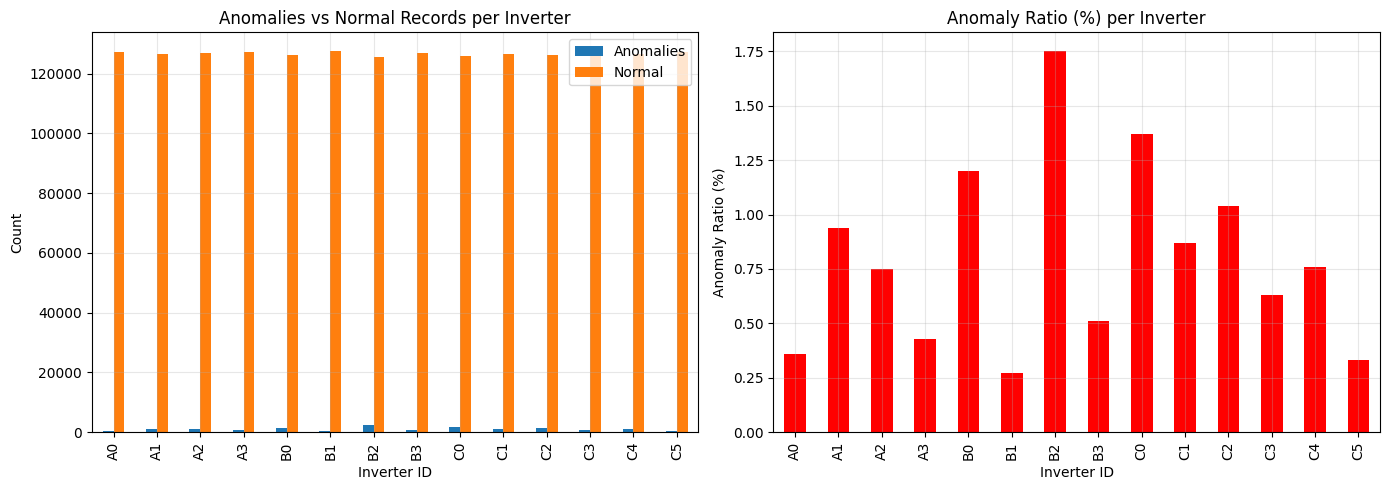

In [12]:
# Analyze anomaly distribution by inverter
anomaly_dist = ad_dataset.groupby('inverter_id')['is_anomaly'].agg([
    ('total', 'count'),
    ('anomalies', 'sum'),
    ('normal', lambda x: (x == 0).sum()),
    ('anomaly_ratio', 'mean')
])
anomaly_dist['anomaly_ratio'] = (anomaly_dist['anomaly_ratio'] * 100).round(2)

print("Anomaly distribution per inverter:")
print(anomaly_dist)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
anomaly_dist[['anomalies', 'normal']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Anomalies vs Normal Records per Inverter')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Inverter ID')
axes[0].legend(['Anomalies', 'Normal'])
axes[0].grid(True, alpha=0.3)

# Ratio plot
anomaly_dist['anomaly_ratio'].plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Anomaly Ratio (%) per Inverter')
axes[1].set_ylabel('Anomaly Ratio (%)')
axes[1].set_xlabel('Inverter ID')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Create Train/Test Splits

For autoencoder-based anomaly detection, autoencoders are typically trained only on normal data. We create:
- **Training set**: All normal records (is_anomaly = 0)
- **Validation set**: Normal records for hyperparameter tuning
- **Test set**: Mix of normal and anomalous records for evaluation

In [13]:
# Separate normal and anomalous data per inverter
train_datasets = []
test_datasets = []

for inverter_id in ad_dataset['inverter_id'].unique():
    inv_data = ad_dataset[ad_dataset['inverter_id'] == inverter_id].copy()
    inv_data = inv_data.sort_values('timestamp').reset_index(drop=True)
    
    # Separate normal and anomalous
    normal_data = inv_data[inv_data['is_anomaly'] == 0].copy()
    anomalous_data = inv_data[inv_data['is_anomaly'] == 1].copy()
    
    # Split normal data: 70% train, 30% validation (for hyperparameter tuning)
    train_size = int(len(normal_data) * 0.7)
    train_data = normal_data.iloc[:train_size].copy()
    val_data = normal_data.iloc[train_size:].copy()
    
    # Test set: anomalous + remaining normal (to have balanced test set)
    test_data = pd.concat([val_data, anomalous_data], ignore_index=True)
    
    train_datasets.append(train_data)
    test_datasets.append(test_data)
    
    print(f"Inverter {inverter_id}:")
    print(f"  Train (normal only): {len(train_data)} records")
    print(f"  Test (normal + anomalies): {len(test_data)} records (anomalies: {(test_data['is_anomaly'] == 1).sum()})")

# Combine all inverters
train_dataset = pd.concat(train_datasets, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
test_dataset = pd.concat(test_datasets, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

print(f"\nCombined:")
print(f"Train dataset: {len(train_dataset)} records (anomalies: {(train_dataset['is_anomaly'] == 1).sum()})")
print(f"Test dataset: {len(test_dataset)} records (anomalies: {(test_dataset['is_anomaly'] == 1).sum()})")

Inverter B1:
  Train (normal only): 89233 records
  Test (normal + anomalies): 38583 records (anomalies: 339)
Inverter B0:
  Train (normal only): 88366 records
  Test (normal + anomalies): 39403 records (anomalies: 1531)
Inverter A0:
  Train (normal only): 89075 records
  Test (normal + anomalies): 38633 records (anomalies: 457)
Inverter A2:
  Train (normal only): 88911 records
  Test (normal + anomalies): 39068 records (anomalies: 963)
Inverter B2:
  Train (normal only): 87922 records
  Test (normal + anomalies): 39913 records (anomalies: 2231)
Inverter A3:
  Train (normal only): 88999 records
  Test (normal + anomalies): 38690 records (anomalies: 547)
Inverter B3:
  Train (normal only): 88954 records
  Test (normal + anomalies): 38777 records (anomalies: 653)
Inverter C1:
  Train (normal only): 88592 records
  Test (normal + anomalies): 39079 records (anomalies: 1110)
Inverter C2:
  Train (normal only): 88400 records
  Test (normal + anomalies): 39208 records (anomalies: 1321)
Invert

Create Input Arrays for Autoencoders

In [14]:
# Extract feature arrays
X_train = train_dataset[feature_cols].values
X_test = test_dataset[feature_cols].values
y_test = test_dataset['is_anomaly'].values

print(f"Training input shape: {X_train.shape} (samples, features)")
print(f"Test input shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nTest set anomaly distribution: {(y_test == 1).sum()} anomalies, {(y_test == 0).sum()} normal")

Training input shape: (1241782, 15) (samples, features)
Test input shape: (546506, 15)
Test labels shape: (546506,)

Test set anomaly distribution: 14303 anomalies, 532203 normal


## Save Data

In [15]:
# Save normalized datasets
train_dataset.to_csv("../data/datasets/anomaly_detection/train_dataset.csv", index=False)
test_dataset.to_csv("../data/datasets/anomaly_detection/test_dataset.csv", index=False)